# Titanic Survival — Exploratory Data Analysis

Elta AI Home Assignment — Data Science Task.

This notebook explores `data/train.csv` (the Kaggle Titanic training set) to
understand feature distributions, missingness, and their relationship with
the target (`Survived`), and to justify the preprocessing choices used in
`src/preprocessing.py` / `train.py`.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/train.csv")
df.shape

(891, 12)

## 1. First look

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 2. Missing values

`Age` (~20%), `Cabin` (~77%), and `Embarked` (2 rows) have missing values.
`Cabin` is too sparse to use directly, but *whether* a passenger has a
recorded cabin turns out to correlate with survival (likely a proxy for
being on an upper deck / higher fare), so we derive a `HasCabin` flag instead
of dropping the column outright.

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": pct})

,missing_count,missing_pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


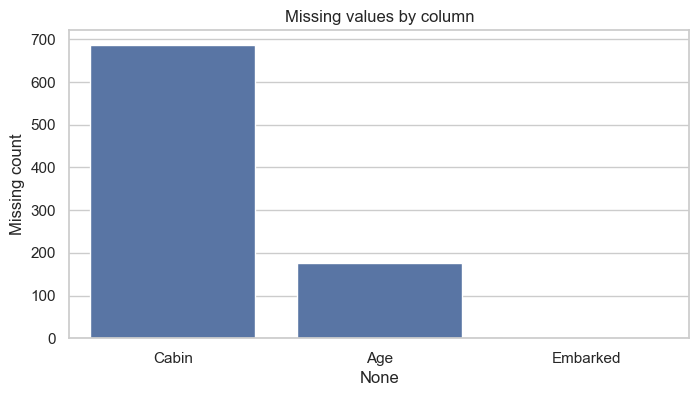

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=missing.index, y=missing.values, ax=ax)
ax.set_ylabel("Missing count")
ax.set_title("Missing values by column")
plt.show()

## 3. Target distribution

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    61.6
1    38.4
Name: count, dtype: float64


C:\Users\Unicorn\AppData\Local\Temp\ipykernel_29428\3723757772.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Died", "Survived"])


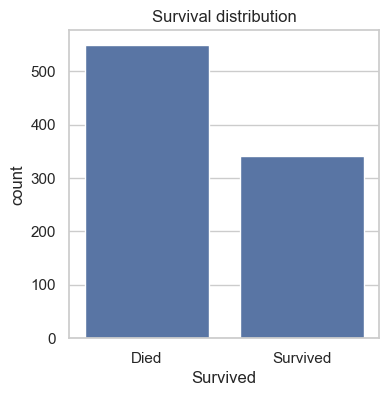

In [7]:
survived_counts = df["Survived"].value_counts()
print(survived_counts)
print((survived_counts / len(df) * 100).round(1))

fig, ax = plt.subplots(figsize=(4, 4))
sns.countplot(x="Survived", data=df, ax=ax)
ax.set_xticklabels(["Died", "Survived"])
ax.set_title("Survival distribution")
plt.show()

~38% of passengers survived — a moderate class imbalance, not extreme.
We account for this in training with a class-weighted loss (`pos_weight`
in `BCEWithLogitsLoss`) rather than resampling, to keep all real data.

## 4. Survival vs. individual features

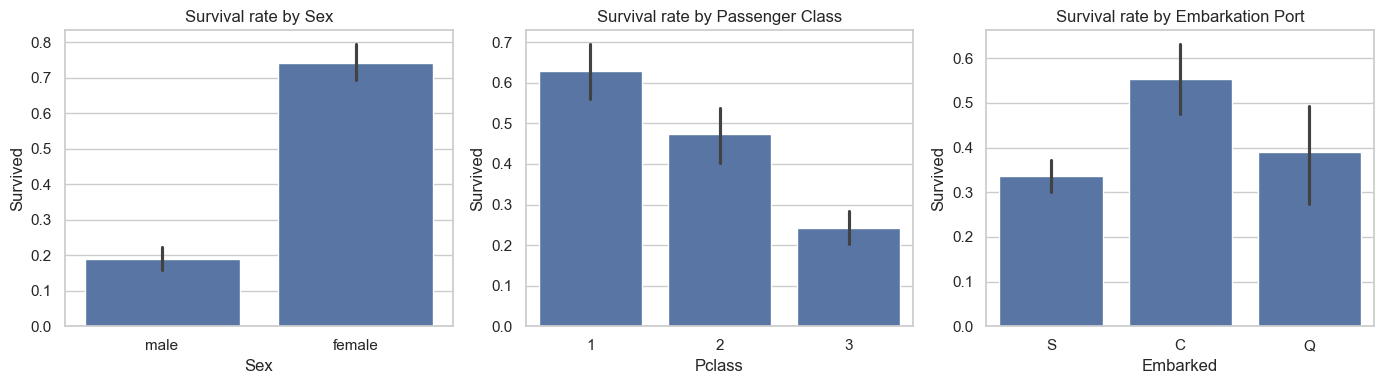

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.barplot(x="Sex", y="Survived", data=df, ax=axes[0])
axes[0].set_title("Survival rate by Sex")

sns.barplot(x="Pclass", y="Survived", data=df, ax=axes[1])
axes[1].set_title("Survival rate by Passenger Class")

sns.barplot(x="Embarked", y="Survived", data=df, ax=axes[2])
axes[2].set_title("Survival rate by Embarkation Port")

plt.tight_layout()
plt.show()

**Sex** is the single strongest predictor (women survived at a much
higher rate — "women and children first"). **Pclass** shows a clear
monotonic relationship (1st class survived most). **Embarked** shows a
weaker but real effect, likely confounded with Pclass (Cherbourg passengers
skewed wealthier).

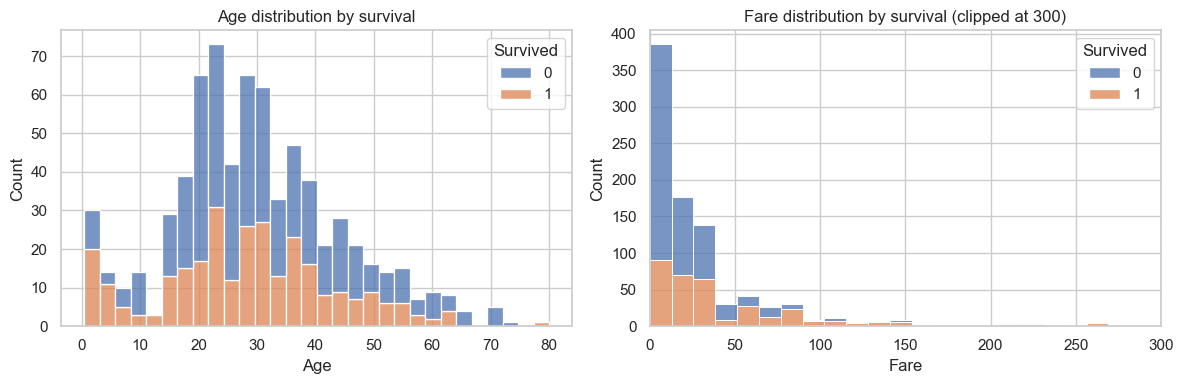

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="Age", hue="Survived", multiple="stack", bins=30, ax=axes[0])
axes[0].set_title("Age distribution by survival")

sns.histplot(data=df, x="Fare", hue="Survived", multiple="stack", bins=40, ax=axes[1])
axes[1].set_xlim(0, 300)
axes[1].set_title("Fare distribution by survival (clipped at 300)")

plt.tight_layout()
plt.show()

Young children show a noticeably higher survival rate. `Fare` is
right-skewed with a clear positive relationship to survival — again likely
correlated with `Pclass` and cabin location.

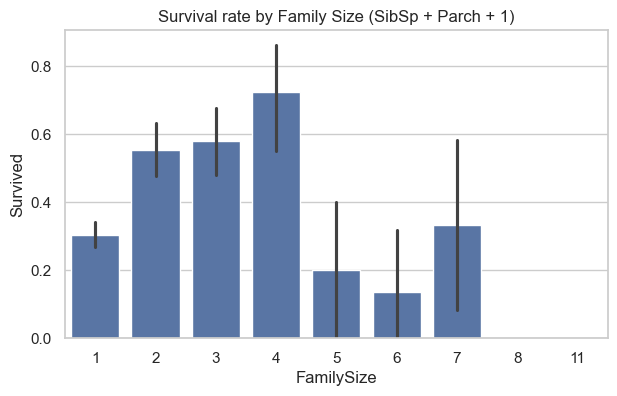

In [10]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x="FamilySize", y="Survived", data=df, ax=ax)
ax.set_title("Survival rate by Family Size (SibSp + Parch + 1)")
plt.show()

Solo travelers (`FamilySize`=1) and very large families (6+) survived
at lower rates than small-to-medium families (2-4) — likely a mix of
"no one to help you" vs. "too many to coordinate/wait for". This
non-monotonic relationship is exactly the kind of signal a raw `SibSp`/
`Parch` split wouldn't capture as cleanly, which is why `FamilySize` is
engineered as its own feature.

### Titles extracted from `Name`

Passenger titles (Mr/Mrs/Miss/Master/rare titles) carry information beyond
raw `Sex` and `Age` — e.g. "Master" reliably identifies young boys, and
rare titles (Dr, Rev, nobility, ...) correlate with class/wealth.

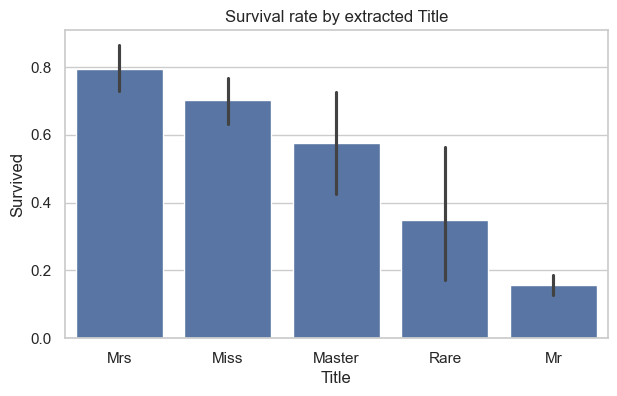

In [11]:
df["Title"] = df["Name"].str.extract(r",\s*([^\.]*)\.", expand=False).str.strip()
title_map = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Rare", "Countess": "Rare", "Capt": "Rare", "Col": "Rare",
    "Don": "Rare", "Dr": "Rare", "Major": "Rare", "Rev": "Rare",
    "Sir": "Rare", "Jonkheer": "Rare",
}
df["Title"] = df["Title"].replace(title_map)
df["Title"] = df["Title"].where(df["Title"].isin(["Mr", "Mrs", "Miss", "Master", "Rare"]), "Rare")

fig, ax = plt.subplots(figsize=(7, 4))
order = df.groupby("Title")["Survived"].mean().sort_values(ascending=False).index
sns.barplot(x="Title", y="Survived", data=df, order=order, ax=ax)
ax.set_title("Survival rate by extracted Title")
plt.show()

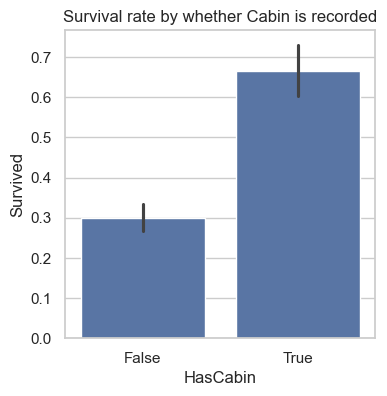

In [12]:
df["HasCabin"] = df["Cabin"].notna()

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(x="HasCabin", y="Survived", data=df, ax=ax)
ax.set_title("Survival rate by whether Cabin is recorded")
plt.show()

## 5. Correlations among numeric features

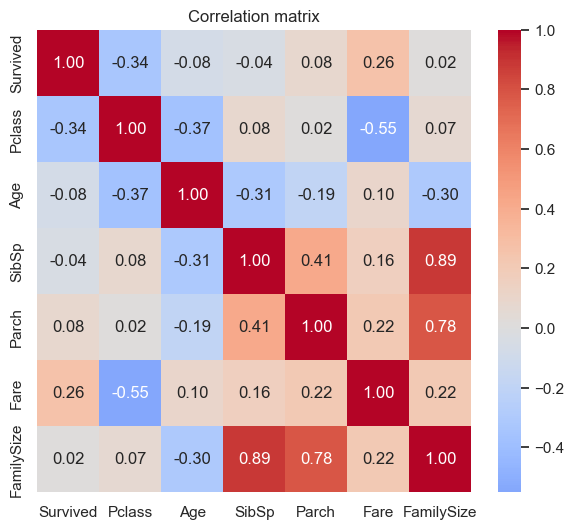

In [13]:
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix")
plt.show()

`Pclass` and `Fare` are (unsurprisingly) correlated with each other and
each has a meaningful correlation with `Survived`. No pair is so strongly
collinear that we need to drop one outright, but this motivates standardizing
numeric features before feeding them to a neural net.

## 5b. Categorical feature association strength (Cramér's V)

The correlation matrix above only covers numeric features — it says nothing
about how strongly `Sex`, `Title`, `Deck`, etc. associate with `Survived`.
**Cramér's V** (bias-corrected, Bergsma & Wicher 2013) is the categorical
analogue: a chi-square-based association statistic normalized to a 0 (no
association) – 1 (perfect association) scale, comparable across features
regardless of how many categories each one has — unlike a raw chi-square
statistic, which grows with the number of categories/rows even when the
underlying association doesn't. This is a purely statistical, model-free
signal computed directly from the data, complementing the permutation
importance computed *after* training in `notebooks/model_benchmark.ipynb`.

We reuse `src.preprocessing.engineer_features` here (rather than re-deriving
`Deck`/`IsAlone` by hand like the rest of this notebook) so the association
numbers reflect the exact categorical features the model actually sees,
including the Deck ticket-mate recovery and T→A merge.

In [14]:
import sys

import scipy.stats as ss

sys.path.insert(0, "..")
from src.preprocessing import engineer_features


def cramers_v(confusion_matrix: np.ndarray) -> float:
    """Bias-corrected Cramer's V (Bergsma & Wicher, 2013) for the strength
    of association between two categorical variables."""
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min(kcorr - 1, rcorr - 1))


engineered = engineer_features(df)
cat_features = ["Pclass", "Sex", "Embarked", "Title", "HasCabin", "Deck", "IsAlone"]

assoc = {}
for col in cat_features:
    ct = pd.crosstab(engineered[col], engineered["Survived"]).to_numpy()
    assoc[col] = cramers_v(ct)

assoc_series = pd.Series(assoc, name="cramers_v").sort_values(ascending=False)
assoc_series.to_frame()

,cramers_v
Title,0.565004
Sex,0.540200
Pclass,0.336684
Deck,0.333389
HasCabin,0.312547
IsAlone,0.198306
Embarked,0.166058


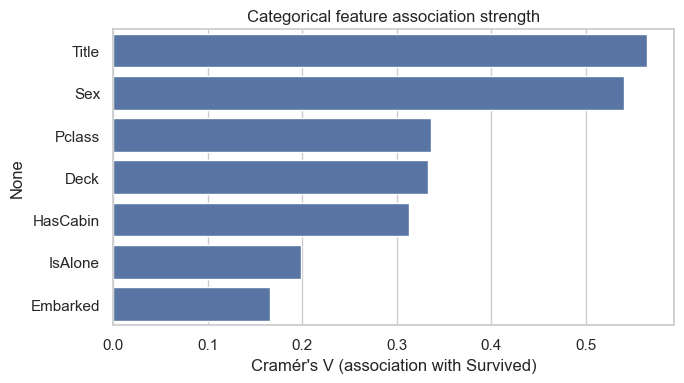

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=assoc_series.values, y=assoc_series.index, ax=ax, orient="h")
ax.set_xlabel("Cramér's V (association with Survived)")
ax.set_title("Categorical feature association strength")
plt.tight_layout()
plt.show()

`Title` (0.57) and `Sex` (0.54) dominate — expected, since they encode
overlapping "women and children first" signal. `Pclass` (0.34) and `Deck`
(0.33) are close behind and nearly tied, with `HasCabin` (0.31) close to
both (unsurprising: whether a cabin was recorded and which deck it was on
are two views of the same underlying signal, itself correlated with
`Pclass`/`Fare`). `IsAlone` (0.20) is weaker but non-trivial,
`Embarked` (0.17) weakest of the group — consistent with the individual
survival-rate plots in Section 4 and the permutation importance computed on
the trained model in `notebooks/model_benchmark.ipynb` (where `Title` and
`Sex` also rank at the top). Unlike some public Titanic EDA notebooks, we
deliberately don't engineer manual two-way interaction columns (e.g.
`Sex__Pclass`) as model inputs — our MLP/Transformer architectures already
learn feature interactions internally through their hidden layers, so
hand-crafted interaction terms would mostly add redundant, sparser columns
without new information for this model family.

## 6. Summary of preprocessing decisions (implemented in `src/preprocessing.py`)

*Updated after adding SOTA-style feature engineering and an architecture
search across three PyTorch models (`mlp`, `deep_mlp`, `tab_transformer`)
in `train.py` — see `notebooks/model_benchmark.ipynb` for the model
comparison this motivated.*

- **Drop**: `PassengerId`, `Name` (after title/surname extraction), `Ticket`
  (after group-size/group-survival extraction), raw `Cabin` (replaced by
  `HasCabin`/`Deck`).
- **Engineer**:
  - `Title` (from `Name`), `FamilySize` (`SibSp + Parch + 1`), `IsAlone`
    (`FamilySize == 1`).
  - `HasCabin` (boolean) and `Deck` (first letter of `Cabin`, `"U"` if
    missing; the single-passenger `"T"` deck is folded into `"A"`, its
    closest real analog, so it isn't a near-unique one-hot column).
  - `TicketGroupSize` (passengers sharing a ticket number) and
    `FarePerPerson` (`Fare / TicketGroupSize`, since the raw fare is the
    whole party's fare).
  - `GroupSurvivalRate` — the fraction of a passenger's travel party
    (same surname + ticket) that survived, computed **leakage-safe**:
    training rows get a leave-one-out rate (excluding their own label),
    validation/inference rows look up their group's train-derived rate with
    a global fallback for unseen groups.
- **Age (~20% missing)**: imputed with the **median age for the
  passenger's Title** (fit on the training split only), not one dataset-
  wide median — Title is highly informative about age (`Master` ≈ 3.5 vs.
  `Mr` ≈ 30 vs. the old single global median of 28 for everyone), so this
  is a large accuracy improvement over naive imputation for a fifth of the
  rows. Falls back to the training set's global median for any
  unseen/missing Title.
- **Other numeric features** (`Fare`, `SibSp`, `Parch`, `FamilySize`,
  `FarePerPerson`, `TicketGroupSize`, `GroupSurvivalRate`): median-impute
  missing values, then standard-scale (`Age` is also scaled after its
  Title-based imputation above).
- **Categorical features** (`Pclass`, `Sex`, `Embarked`, `Title`,
  `HasCabin`, `Deck`, `IsAlone`): most-frequent-impute missing values, then
  one-hot encode (`TitanicPreprocessor`, for the MLP architectures) or
  ordinal-encode into per-column tokens (`TitanicTokenizer`, for the
  TabTransformer).
- The preprocessing pipeline is **fit only on the training split** and
  reused (transform-only) on the validation split and at inference time, to
  avoid data leakage.